In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

In [2]:
# Load the dataset from CSV

In [3]:
df = pd.read_csv('Downloads/amazon_sales_dataset.csv')

In [4]:
# Preview first 5 rows

In [5]:
print("=== FIRST 5 ROWS ===")
df.head()

=== FIRST 5 ROWS ===


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [6]:
# Preview last 5 rows

In [7]:
print("=== LAST 5 ROWS ===")
df.tail()

=== LAST 5 ROWS ===


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16
49999,50000,2023-06-29,2944,Home & Kitchen,253.44,30,1,Europe,Debit Card,2.1,464,177.41,177.41


In [8]:
# Check data types and non-null counts

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [10]:
# Check for missing values in each column

In [11]:
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing)
print(f"\n Total missing values: {missing.sum()}")

Missing Values per Column:
order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

 Total missing values: 0


In [12]:
# Check for duplicate rows

In [13]:
dups = df.duplicated().sum()
print(f"Duplicate rows found: {dups}")
print("No duplicates — dataset is clean.")

Duplicate rows found: 0
No duplicates — dataset is clean.


In [14]:
# Convert order_date from string to datetime

In [15]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [16]:
# Descriptive statistics for key numeric columns

In [17]:
df[['price','discount_percent','quantity_sold',
    'discounted_price','total_revenue','rating']].describe().round(2)

,price,discount_percent,quantity_sold,discounted_price,total_revenue,rating
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,252.51,13.34,3.00,218.89,657.33,3.00
std,143.03,9.85,1.42,127.32,526.22,1.15
min,5.01,0.00,1.00,3.53,3.84,1.00
25%,127.84,5.00,2.00,109.68,240.32,2.00
50%,252.97,10.00,3.00,215.80,505.41,3.00
75%,376.34,20.00,4.00,322.70,968.97,4.00
max,499.99,30.00,5.00,499.91,2499.55,5.00


In [18]:
# EDA QUESTION 1: OVERALL SALES PERFORMANCE

In [19]:
total_revenue      = df['total_revenue'].sum()
total_qty          = df['quantity_sold'].sum()
total_discount     = df['discounted_price'].sum()
price              = df['price'].sum()
total_orders       = len(df)
avg_order_value    = total_revenue / total_orders
discount_rate_pct  = (total_discount / price) * 100
print("=" * 55)
print("       OVERALL SALES PERFORMANCE SUMMARY")
print("=" * 55)
print(f"  Total Revenue (Actual):       ${total_revenue:>15,.2f}")
print(f"  Price :                       ${price:>15,.2f}")
print(f"  Total Discounted Price:         ${total_discount:>15,.2f}")
print(f"  Discount Rate:                {discount_rate_pct:>14.2f}%")
print(f"  Total Quantity Sold:          {total_qty:>15,}")
print(f"  Total Orders:                 {total_orders:>15,}")
print(f"  Average Order Value:          ${avg_order_value:>15.2f}")
print("=" * 55)

       OVERALL SALES PERFORMANCE SUMMARY
  Total Revenue (Actual):       $  32,866,573.74
  Price :                       $  12,625,363.00
  Total Discounted Price:         $  10,944,328.29
  Discount Rate:                         86.69%
  Total Quantity Sold:                  149,970
  Total Orders:                          50,000
  Average Order Value:          $         657.33


In [20]:
# time features

In [21]:
df['year']       = df['order_date'].dt.year
df['month']      = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')
df['month_year'] = df['order_date'].dt.to_period('M')


In [22]:
print(f"\n New feature columns added:")
print(f"   year, month, month_name, month_year,")


 New feature columns added:
   year, month, month_name, month_year,


In [23]:
# Custom colour palette

In [24]:
PAL   = ['#1B3A6B','#0D7377','#F4A300','#E74C3C','#27AE60','#8E44AD']
NAVY  = '#1B3A6B'
TEAL  = '#0D7377'
GOLD  = '#F4A300'


In [46]:
# EDA QUESTION 2: SALES TREND OVER TIME

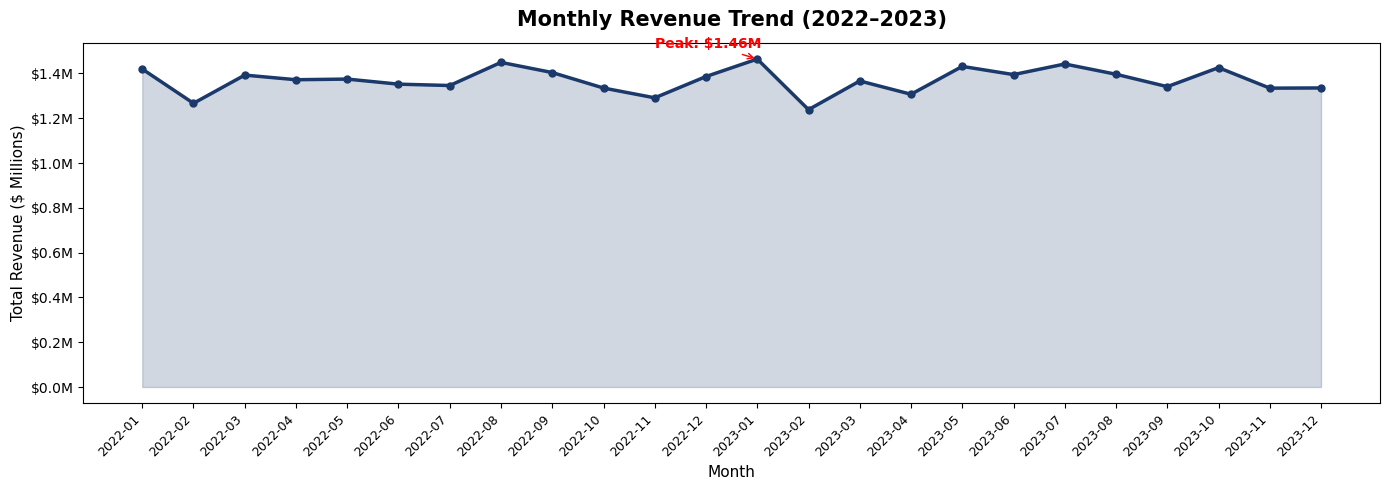

Chart saved: chart_08a_monthly revenue trend.png


In [45]:
monthly = df.groupby('month_year')['total_revenue'].sum().reset_index()
monthly['month_year_str'] = monthly['month_year'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(range(len(monthly)), monthly['total_revenue'] / 1e6,
                alpha=0.20, color=NAVY)
ax.plot(range(len(monthly)), monthly['total_revenue'] / 1e6,
        color=NAVY, linewidth=2.5, marker='o', markersize=5, zorder=5)

# Annotate peak month
peak_idx = monthly['total_revenue'].idxmax()
ax.annotate(f"Peak: ${monthly.loc[peak_idx,'total_revenue']/1e6:.2f}M",
            xy=(peak_idx, monthly.loc[peak_idx,'total_revenue']/1e6),
            xytext=(peak_idx-2, monthly.loc[peak_idx,'total_revenue']/1e6 + 0.05),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['month_year_str'], rotation=45, ha='right', fontsize=9)
ax.set_title('Monthly Revenue Trend (2022–2023)', fontsize=15, fontweight='bold', pad=12)
ax.set_ylabel('Total Revenue ($ Millions)', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
plt.tight_layout()
plt.show()
print("Chart saved: chart_08a_monthly revenue trend.png")

In [27]:
# EDA QUESTION 3: CATEGORY PERFORMANCE

In [28]:
cat_stats = (
    df.groupby('product_category')
    .agg(
        Revenue      = ('total_revenue',   'sum'),
        Discount     = ('discounted_price',  'sum'),
        Orders       = ('order_id',        'count'),
        Avg_Qty      = ('quantity_sold',   'mean'),
        Avg_Rating   = ('rating',          'mean')
    )
    .sort_values('Revenue', ascending=False)
    .reset_index()
)
cat_stats['Discount_Rate_%'] = (
    cat_stats['Discount'] / cat_stats['Revenue'] * 100
).round(2)

print("\n Category Performance Table:")
print(cat_stats[['product_category', 'Revenue', 'Discount',
                  'Discount_Rate_%', 'Orders', 'Avg_Rating']].round(2).to_string(index=False))


 Category Performance Table:
product_category    Revenue   Discount  Discount_Rate_%  Orders  Avg_Rating
          Beauty 5550624.97 1851147.17            33.35    8465        2.99
           Books 5484863.03 1821420.74            33.21    8327        3.02
         Fashion 5480123.34 1828953.82            33.37    8365        2.99
  Home & Kitchen 5473132.55 1820658.51            33.27    8258        3.00
     Electronics 5470594.03 1820713.68            33.28    8320        2.99
          Sports 5407235.82 1801434.37            33.32    8265        3.00


In [49]:
# ── Plot Revenue vs Discount by Category ─────────

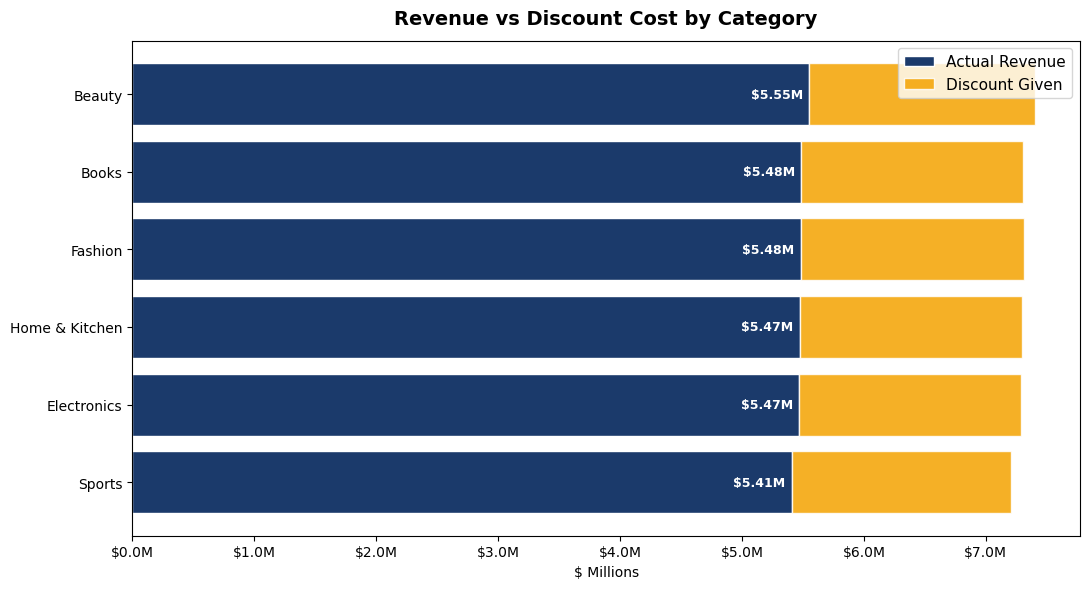

Chart saved: chart_03_category_performance.png


In [51]:
cats_sorted = cat_stats.sort_values('Revenue')
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(
    cats_sorted['product_category'],
    cats_sorted['Revenue'] / 1e6,
    color=NAVY, edgecolor='white', label='Actual Revenue'
)
ax.barh(
    cats_sorted['product_category'],
    cats_sorted['Discount'] / 1e6,
    left=cats_sorted['Revenue'] / 1e6,
    color=GOLD, edgecolor='white', alpha=0.85, label='Discount Given'
)
ax.set_title('Revenue vs Discount Cost by Category', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('$ Millions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax.legend(fontsize=11)
for i, row in enumerate(cats_sorted.itertuples()):
    ax.text(
        row.Revenue / 1e6 - 0.05, i,
        f'${row.Revenue / 1e6:.2f}M',
        va='center', ha='right', fontsize=9, color='white', fontweight='bold'
    )
plt.tight_layout()
plt.savefig('chart_03_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: chart_03_category_performance.png")


In [29]:
# EDA QUESTION 4: SUB-CATEGORY / TOP CATEGORY ANALYSIS

In [30]:
top5_rev  = cat_stats.nlargest(5, 'Revenue')[['product_category', 'Revenue']]
top5_disc = cat_stats.nlargest(5, 'Discount')[['product_category', 'Discount']]

print("\n Top 5 by Revenue:")
for i, row in top5_rev.iterrows():
    print(f"   {row['product_category']:<20} ${row['Revenue']:>12,.2f}")

print("\n Top 5 by Discount Given:")
for i, row in top5_disc.iterrows():
    print(f"   {row['product_category']:<20} ${row['Discount']:>12,.2f}")


 Top 5 by Revenue:
   Beauty               $5,550,624.97
   Books                $5,484,863.03
   Fashion              $5,480,123.34
   Home & Kitchen       $5,473,132.55
   Electronics          $5,470,594.03

 Top 5 by Discount Given:
   Beauty               $1,851,147.17
   Fashion              $1,828,953.82
   Books                $1,821,420.74
   Electronics          $1,820,713.68
   Home & Kitchen       $1,820,658.51


In [31]:
# ── Plot 4: Side-by-side top-5 charts ────────

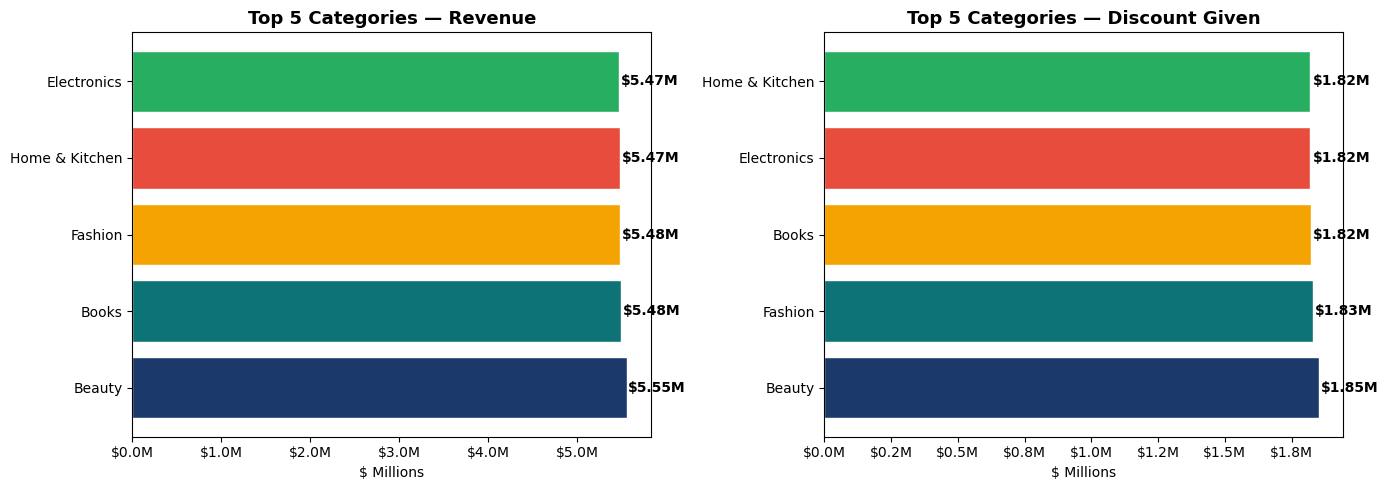

Chart saved: chart_08a_categories by revenue and by discount given.png


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top5_rev['product_category'], top5_rev['Revenue'] / 1e6,
             color=PAL[:5], edgecolor='white')
axes[0].set_title('Top 5 Categories — Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('$ Millions')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
for i, v in enumerate(top5_rev['Revenue'] / 1e6):
    axes[0].text(v + 0.02, i, f'${v:.2f}M', va='center', fontsize=10, fontweight='bold')

axes[1].barh(top5_disc['product_category'], top5_disc['Discount'] / 1e6,
             color=PAL[:5], edgecolor='white')
axes[1].set_title('Top 5 Categories — Discount Given', fontsize=13, fontweight='bold')
axes[1].set_xlabel('$ Millions')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
for i, v in enumerate(top5_disc['Discount'] / 1e6):
    axes[1].text(v + 0.01, i, f'${v:.2f}M', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_04_top5_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: chart_08a_categories by revenue and by discount given.png")

In [33]:
# EDA QUESTION 5: REGIONAL PERFORMANCE

In [34]:
reg = (
    df.groupby('customer_region')
    .agg(
        Revenue    = ('total_revenue',  'sum'),
        Discount   = ('discounted_price', 'sum'),
        Orders     = ('order_id',       'count'),
        Avg_Order  = ('total_revenue',  'mean'),
        Avg_Rating = ('rating',         'mean')
    )
    .sort_values('Revenue', ascending=False)
    .reset_index()
)

print("\n Regional Performance Table:")
print(reg.round(2).to_string(index=False))


 Regional Performance Table:
customer_region    Revenue   Discount  Orders  Avg_Order  Avg_Rating
    Middle East 8301844.50 2744215.15   12505     663.88        3.02
  North America 8277217.84 2749604.35   12517     661.28        3.00
           Asia 8175199.83 2733376.41   12526     652.66        3.00
         Europe 8112311.57 2717132.38   12452     651.49        2.97


In [35]:
# EDA QUESTION 6: PROFITABILITY / DISCOUNT ANALYSIS

In [36]:
disc_tier_stats = (
    df.groupby('product_category')
    .agg(
        Revenue         = ('total_revenue', 'sum'),
        Orders          = ('order_id',      'count'),
        Avg_Order_Value = ('total_revenue', 'mean')
    )
    .reset_index()
)

print("\n Revenue by product_category:")
print(disc_tier_stats.round(2).to_string(index=False))




 Revenue by product_category:
product_category    Revenue  Orders  Avg_Order_Value
          Beauty 5550624.97    8465           655.71
           Books 5484863.03    8327           658.68
     Electronics 5470594.03    8320           657.52
         Fashion 5480123.34    8365           655.13
  Home & Kitchen 5473132.55    8258           662.77
          Sports 5407235.82    8265           654.23


In [37]:
# EDA QUESTION 7: CUSTOMER PURCHASING BEHAVIOUR

In [38]:
qty_counts = df['quantity_sold'].value_counts().sort_index()
qty_pct    = qty_counts / qty_counts.sum() * 100

print("\n Order Quantity Distribution:")
print("-" * 45)
for qty, cnt in qty_counts.items():
    pct = qty_pct[qty]
    print(f"  Qty {qty}: {cnt:6,} orders  ({pct:.1f}%)")
print("-" * 45)




 Order Quantity Distribution:
---------------------------------------------
  Qty 1: 10,060 orders  (20.1%)
  Qty 2:  9,914 orders  (19.8%)
  Qty 3: 10,026 orders  (20.1%)
  Qty 4:  9,996 orders  (20.0%)
  Qty 5: 10,004 orders  (20.0%)
---------------------------------------------


In [39]:
#EDA QUESTION 8: RELATIONSHIP ANALYSIS

In [40]:
corr_cols = [
    'price', 'discount_percent', 'quantity_sold',
    'discounted_price', 'total_revenue', 'rating', 'review_count'
]
corr = df[corr_cols].corr()

print("\n Correlation Matrix:")
print(corr.round(3).to_string())

print("\n Top Correlations with Total Revenue:")
print("-" * 50)
rev_corr = corr['total_revenue'].drop('total_revenue').sort_values(ascending=False)
for var, val in rev_corr.items():
    direction = '↑ Positive' if val > 0 else '↓ Negative'
    print(f"  {var:<25} {val:>7.3f}   ({direction})")



 Correlation Matrix:
                  price  discount_percent  quantity_sold  discounted_price  total_revenue  rating  review_count
price             1.000            -0.005          0.004             0.975          0.711   0.006         0.001
discount_percent -0.005             1.000          0.001            -0.199         -0.144   0.004         0.005
quantity_sold     0.004             0.001          1.000             0.004          0.594  -0.003         0.001
discounted_price  0.975            -0.199          0.004             1.000          0.730   0.006         0.001
total_revenue     0.711            -0.144          0.594             0.730          1.000   0.002         0.002
rating            0.006             0.004         -0.003             0.006          0.002   1.000        -0.003
review_count      0.001             0.005          0.001             0.001          0.002  -0.003         1.000

 Top Correlations with Total Revenue:
-------------------------------------------

In [41]:
# ── Correlation Heatmap ─────

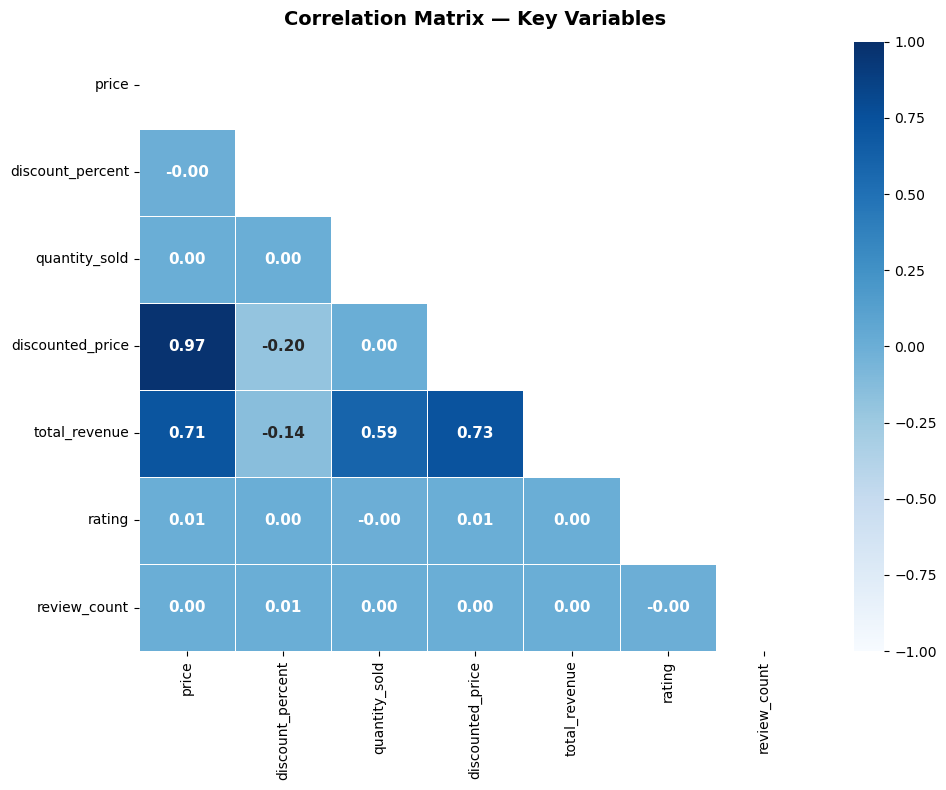

Chart saved: chart_08a_correlation_heatmap.png


In [42]:
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='Blues', ax=ax,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    vmin=-1, vmax=1
)
ax.set_title('Correlation Matrix — Key Variables',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('chart_08a_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: chart_08a_correlation_heatmap.png")